In [1]:
import numpy as np
from matplotlib import pyplot as plt

import sklearn
import urllib.request

import pandas as pd

In [2]:
import tensorflow as tf

2026-06-18 20:53:33.921385: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-06-18 20:53:34.082231: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-06-18 20:53:36.290957: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [3]:
import torch 
import torchvision

In [4]:
data = pd.read_csv("../solutions/galaxyquasar.csv")
data

,u,g,r,i,z,class,z1,zerr
0,18.97213,18.53676,18.58280,18.34936,18.29215,QSO,0.522819,0.000155
1,19.24592,17.47646,16.47817,16.04472,15.68851,GALAXY,0.122846,0.000028
2,19.43536,17.70268,16.91565,16.58327,16.39128,GALAXY,0.000000,0.000000
3,19.31626,18.18312,17.39591,16.94549,16.65395,GALAXY,0.147435,0.000009
4,19.28828,19.11188,18.88937,18.80013,18.49183,QSO,2.011455,0.000631
...,...,...,...,...,...,...,...,...
49995,19.37295,18.12382,17.39886,16.98503,16.70585,GALAXY,0.113016,0.000011
49996,18.52021,16.88262,16.03280,15.56884,15.22454,GALAXY,0.085063,0.000014
49997,18.62718,17.30876,16.87371,16.62399,16.42296,GALAXY,0.054429,0.000008
49998,19.55140,18.27711,17.62101,17.21947,17.03347,GALAXY,0.112571,0.000009


In [5]:
cls = []
for c in data['class']:
    if c=='QSO': cls = np.append(cls, 1)
    elif c=='GALAXY': cls = np.append(cls, 0)

In [6]:
u_g = np.array(data['u']-data['g'])
g_r = np.array(data['g']-data['r'])
r_i = np.array(data['r']-data['i'])
i_z = np.array(data['i']-data['z'])
z = np.array(data['z1'])
zerr = np.array(data['zerr'])

In [7]:
from sklearn.naive_bayes import GaussianNB

X = np.array([u_g, g_r, r_i, i_z, z]).T
y = cls

gnb = GaussianNB()
gnb.fit(X,y)

y_pred = gnb.predict(X)
X.shape, y.shape

((50000, 5), (50000,))

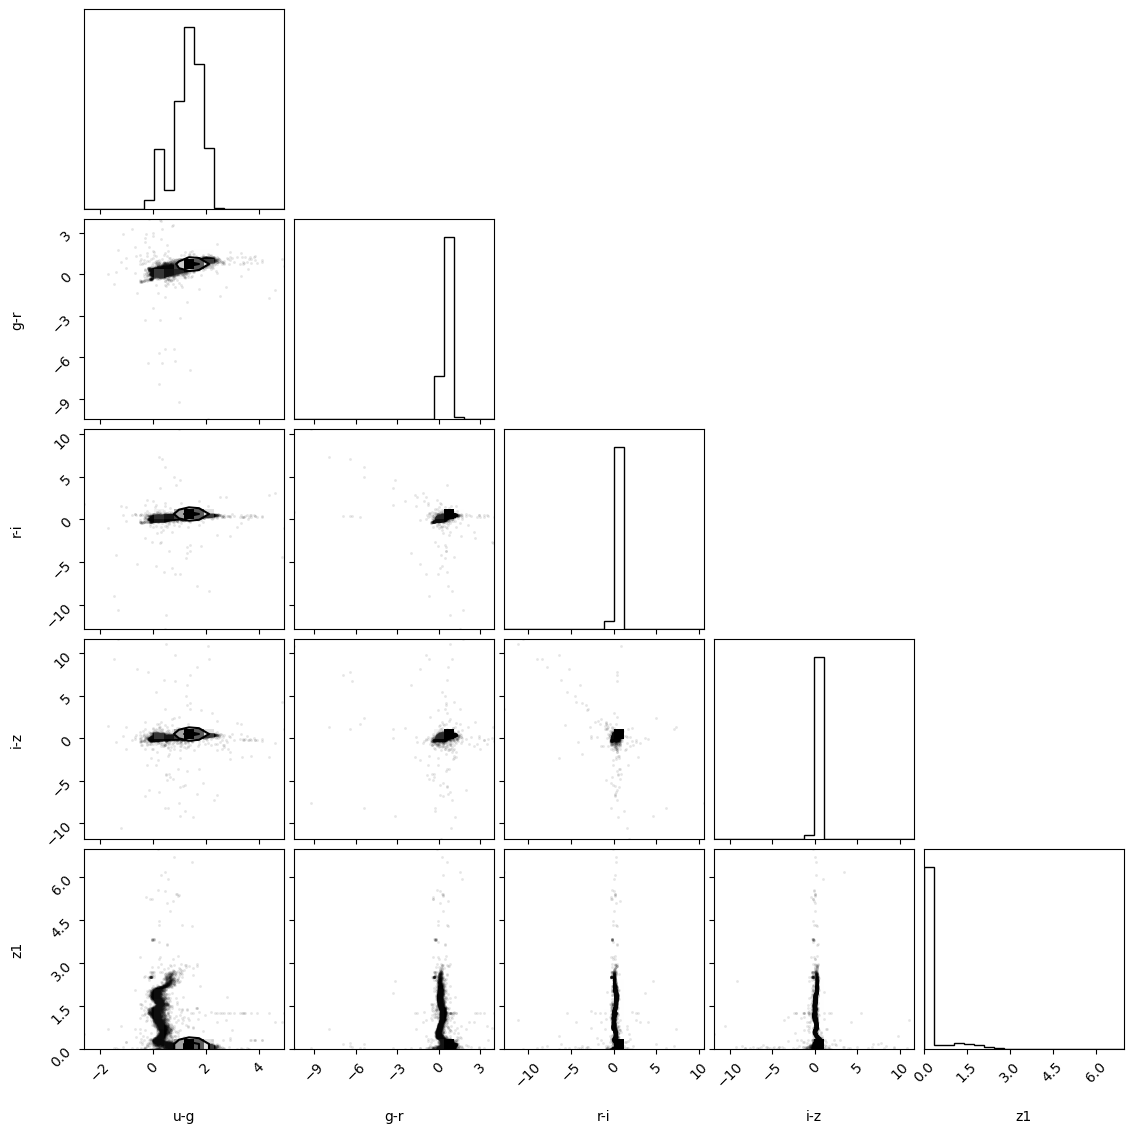

In [8]:
import corner
corner.corner(np.array([u_g,g_r,r_i,i_z,z]).T, labels=['u-g', 'g-r', 'r-i', 'i-z','z1']);

In [41]:
from sklearn.naive_bayes import GaussianNB
from astroML.utils import split_samples
from astroML.utils import completeness_contamination
from sklearn.metrics import precision_recall_curve, roc_curve
from sklearn.preprocessing import StandardScaler

sc = StandardScaler()
Xs = sc.fit_transform(X)

(X_train_full, X_test_full), (y_train_full, y_test_full) = split_samples(Xs, y, [0.75, 0.25],
                                                     random_state=0)

X_train_full.shape, y_train_full.shape

((37500, 5), (37500,))

In [57]:
from tensorflow import keras


keras.backend.clear_session() # Make sure that we are starting a new model and not adding to an earlier one
np.random.seed(42) # Set the numpy and tensorflow random seeds so that we all get the same answer
tf.random.set_seed(42)



X_valid, X_train = X_train_full[:12000], X_train_full[12000:]
y_valid, y_train = y_train_full[:12000], y_train_full[12000:]
X_test = X_test_full 
y_test = y_test_full

print(X_train.shape, y_train.shape)
print(X_valid.shape, y_valid.shape)
print(X_test.shape, y_test.shape)


(25500, 5) (25500,)
(12000, 5) (12000,)
(12500, 5) (12500,)


In [58]:
X_train = X_train[:,:,np.newaxis]
X_valid = X_valid[:,:,np.newaxis]
X_test = X_test[:,:,np.newaxis]

print(X_train.shape, y_train.shape)
print(X_valid.shape, y_valid.shape)
print(X_test.shape, y_test.shape)

(25500, 5, 1) (25500,)
(12000, 5, 1) (12000,)
(12500, 5, 1) (12500,)


In [59]:
model = keras.models.Sequential([
    keras.layers.InputLayer(input_shape=(5,1)),
    keras.layers.Conv1D(filters=64, kernel_size=7, activation='relu', padding='same'),
    keras.layers.Dropout(0.3),
    keras.layers.MaxPooling1D(pool_size=2),
    keras.layers.Conv1D(128, 3, activation='relu', padding='same'),
    keras.layers.Dropout(0.3),
    keras.layers.Conv1D(128, 3, activation='relu', padding='same'),
    keras.layers.MaxPooling1D(pool_size=2),
    keras.layers.Conv1D(128, 3, activation='relu', padding='same'),
    keras.layers.Dropout(0.3),
    keras.layers.Conv1D(128, 3, activation='relu', padding='same'),
    keras.layers.Flatten(),
    keras.layers.Dense(units=128, activation='relu'),
    keras.layers.Dropout(0.5), 
    keras.layers.Dense(units=64, activation='relu'), 
    keras.layers.Dropout(0.5),
    keras.layers.Dense(units=2, activation='softmax'),
])

/home/elisa/miniconda3/envs/fermipy/lib/python3.9/site-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


In [60]:
print(model.summary())

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 5, 64)          │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 5, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 2, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 2, 128)         │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 2, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 2, 128)         │        49,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 1, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ (None, 1, 128)         │        49,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 1, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_4 (Conv1D)               │ (None, 1, 128)         │        49,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 197,954 (773.26 KB)

 Trainable params: 197,954 (773.26 KB)

 Non-trainable params: 0 (0.00 B)

None


In [61]:
# last_epoch = 30

# model.compile(loss="sparse_categorical_crossentropy", optimizer=keras.optimizers.Nadam(learning_rate=0.0001), metrics=["accuracy"])
# clf = model.fit(X_train, y_train, epochs=last_epoch, validation_data=(X_valid, y_valid))
last_epoch = 15 # Increased epochs as training might take longer with callbacks and lower LR

early_stopping_cb = keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True)
reduce_lr_cb = keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=5, min_lr=0.0001)


model.compile(loss="sparse_categorical_crossentropy", optimizer=keras.optimizers.Nadam(learning_rate=0.0001), metrics=["accuracy"])
clf = model.fit(X_train, y_train, epochs=last_epoch, validation_data=(X_valid, y_valid), callbacks=[early_stopping_cb, reduce_lr_cb])

Epoch 1/15
797/797 ━━━━━━━━━━━━━━━━━━━━ 12s 13ms/step - accuracy: 0.9046 - loss: 0.3330 - val_accuracy: 0.9886 - val_loss: 0.0757 - learning_rate: 1.0000e-04
Epoch 2/15
797/797 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.9873 - loss: 0.0750 - val_accuracy: 0.9892 - val_loss: 0.0535 - learning_rate: 1.0000e-04
Epoch 3/15
797/797 ━━━━━━━━━━━━━━━━━━━━ 11s 12ms/step - accuracy: 0.9885 - loss: 0.0555 - val_accuracy: 0.9894 - val_loss: 0.0504 - learning_rate: 1.0000e-04
Epoch 4/15
797/797 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - accuracy: 0.9890 - loss: 0.0530 - val_accuracy: 0.9894 - val_loss: 0.0459 - learning_rate: 1.0000e-04
Epoch 5/15
797/797 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - accuracy: 0.9893 - loss: 0.0486 - val_accuracy: 0.9899 - val_loss: 0.0478 - learning_rate: 1.0000e-04
Epoch 6/15
797/797 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.9899 - loss: 0.0399 - val_accuracy: 0.9899 - val_loss: 0.0405 - learning_rate: 1.0000e-04
Epoch 7/15
797/797 ━━━━━━━━━━━━━━━━━━━━ 11s 13ms/step 

In [62]:
X_new = X_test[:20]
y_proba = model.predict(X_new).round(4)
y_proba

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step


array([[9.977e-01, 2.300e-03],
       [9.999e-01, 1.000e-04],
       [9.999e-01, 1.000e-04],
       [9.999e-01, 1.000e-04],
       [1.100e-03, 9.989e-01],
       [9.985e-01, 1.500e-03],
       [9.999e-01, 1.000e-04],
       [9.998e-01, 2.000e-04],
       [9.999e-01, 1.000e-04],
       [9.999e-01, 1.000e-04],
       [9.983e-01, 1.700e-03],
       [9.999e-01, 1.000e-04],
       [9.999e-01, 1.000e-04],
       [9.999e-01, 1.000e-04],
       [9.997e-01, 3.000e-04],
       [9.999e-01, 1.000e-04],
       [9.999e-01, 1.000e-04],
       [9.977e-01, 2.300e-03],
       [1.000e+00, 0.000e+00],
       [1.000e-04, 9.999e-01]], dtype=float32)

In [63]:
y_pred = np.argmax(model.predict(X_test), axis=-1)

391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step


In [64]:
completeness, contamination = completeness_contamination(y_pred, y_test)

print("completeness", completeness)
print("contamination", contamination)

completeness 0.9642857142857143
contamination 0.024655963302752295


In [65]:
model

<Sequential name=sequential, built=True>

In [66]:
def predict_prob(number):
  return [number[0],1-number[0]]

y_prob = np.array(list(map(predict_prob, model.predict(X_test))))[:,1]
y_prob.shape 

391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


(12500,)

In [67]:
fpr, tpr, thresh = roc_curve(y_test, y_prob)

(0.9, 1.0)

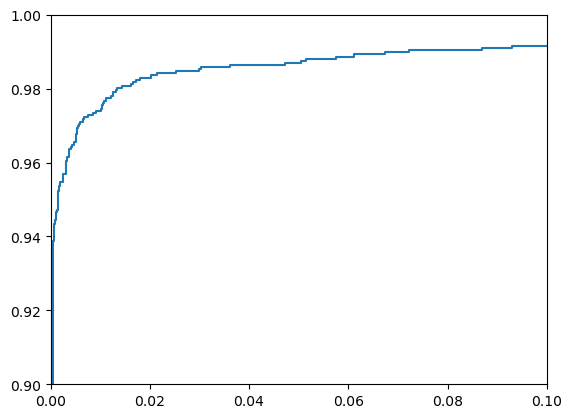

In [68]:
plt.plot(fpr,tpr)
plt.xlim(0,0.1)
plt.ylim(0.9,1)

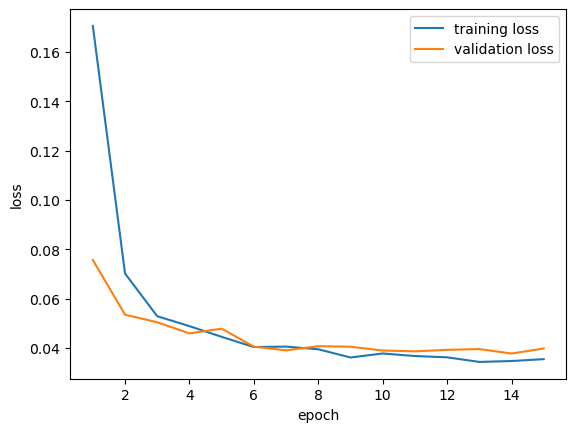

In [69]:
last_epoch = len(clf.history['loss'])
epochs = np.arange(1,last_epoch+1)
plt.plot(epochs,clf.history['loss'], label='training loss')
plt.plot(epochs,clf.history['val_loss'], label='validation loss')
plt.xlabel('epoch')
plt.ylabel('loss')

plt.legend();

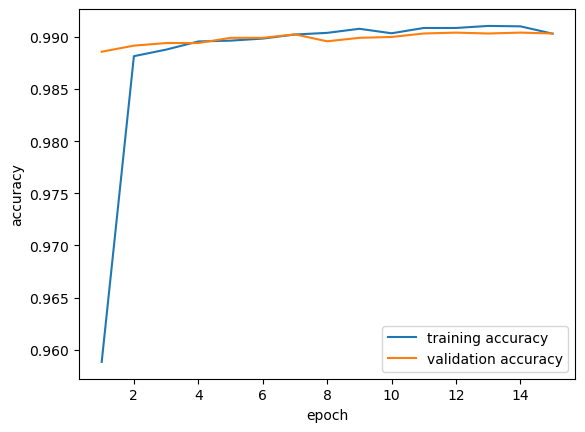

In [70]:
epochs = np.arange(1,last_epoch+1)
plt.plot(epochs,clf.history['accuracy'], label='training accuracy')
plt.plot(epochs,clf.history['val_accuracy'], label='validation accuracy')
plt.xlabel('epoch')
plt.ylabel('accuracy')

plt.legend();